In [ ]:
!pip install -q surprise
!pip install numpy==1.25.2 --force-reinstall
!pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 96.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.25.2 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.25.2 which is incompatible.
blosc2 3.3.1 requires numpy>=1.26, but you have numpy 1.25.2 which is incompatible.


In [ ]:
import pandas as pd
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split as surprise_train_test_split
from sklearn.model_selection import train_test_split as sklearn_train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from surprise.accuracy import rmse

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/CMPE 256 -- Advanced Data Mining/main_derived.csv"
df = pd.read_csv(path)
df["sport_copy"] = df["sport"]
labelencoder = LabelEncoder()
df['sport'] = labelencoder.fit_transform(df['sport'])
df.head()

,distance,duration,gender,heart_rate,sport,userId,calories,sport_copy
0,56.245906,10810.0,male,142.672,3,139383,3757.00,bike
1,53.232915,10798.0,male,137.844,3,139383,3472.00,bike
2,9.404775,4838.0,male,158.678,26,212295,1054.00,run
3,5.550355,2916.0,male,154.348,26,212295,620.00,run
4,26.138077,6713.0,male,140.208,3,139383,1529.96,bike


In [ ]:
df = df[df['heart_rate'] > 0] # Drop 470 rows with 0 heart rate or negative
(df['heart_rate'] <= 0).sum()

0

### SVD Approach

In [ ]:
df_cat = df.copy()
reader = Reader(rating_scale=(1,211))
train_data = Dataset.load_from_df(df_cat, reader)
trainingSet, testSet = surprise_train_test_split(train_data, test_size=0.3, train_size=None, random_state=None, shuffle=True)

In [ ]:
svd = SVD(n_factors=100, n_epochs=20, verbose=True)
svd.fit(trainingSet)
predictions_svd = svd.test(testSet)

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19


In [ ]:
svd_acc = rmse(predictions_svd)
print(f"SVD RMSE: {svd_acc}")

RMSE: 12.4520
SVD RMSE: 12.452033093626754


### KNN Approach

In [ ]:
trainingSet, testSet = sklearn_train_test_split(df, test_size=0.25, train_size=None, random_state=None, shuffle=True)

In [ ]:
X = trainingSet.drop('sport', axis=1)
y = trainingSet['sport']
X_test = testSet.drop('sport', axis=1)
y_test = testSet['sport']

In [ ]:
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)

KNeighborsClassifier(n_neighbors=20)

In [ ]:
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy}")

KNN Accuracy: 0.8366074664733599


##Conclusion
At a baseline level, we can see KNN performed the best in regards to highest accuracy so it will serve as our baseline. SVD had struggled due to seeing heart rate as an "item" so more parameters will need to be tested to replace heart rate, with the hope that it improves accuracy.

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from surprise import Dataset, Reader, SVD, accuracy
from surprise.prediction_algorithms.predictions import Prediction
from surprise import Dataset, Reader, KNNBaseline, accuracy
import numpy as np

path = "/content/drive/MyDrive/CMPE 256 -- Advanced Data Mining/main_timestamp.csv"
df = pd.read_csv(path)
df["sport_copy"] = df["sport"]
labelencoder = LabelEncoder()
df['sport'] = labelencoder.fit_transform(df['sport'])
df.head()

# Add calories per minute
df["calories_per_minute"] = df["calories"] / (df["duration"] / 60)


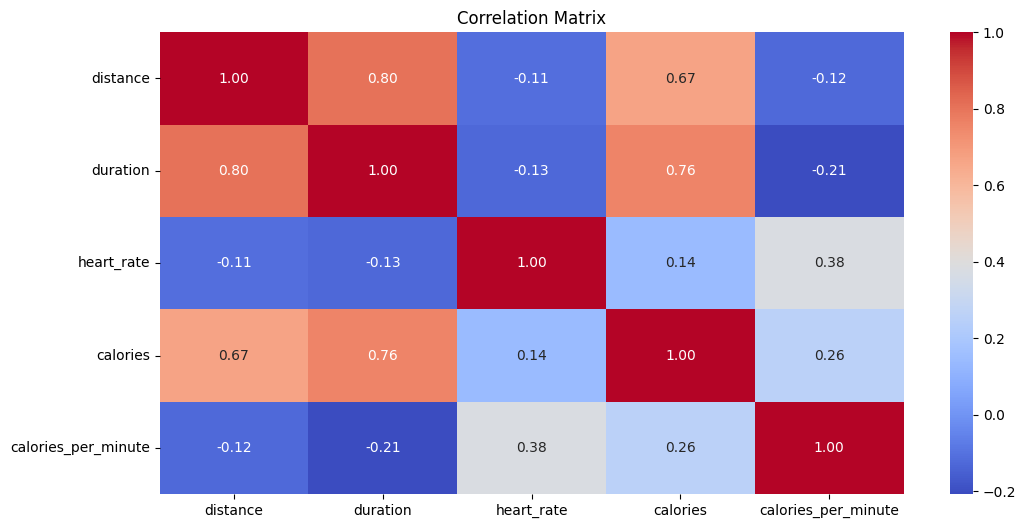

In [166]:
numeric_features = ['distance', 'duration', 'heart_rate', 'calories', 'calories_per_minute']

#Correlation Matrix
correlation_matrix = df[numeric_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


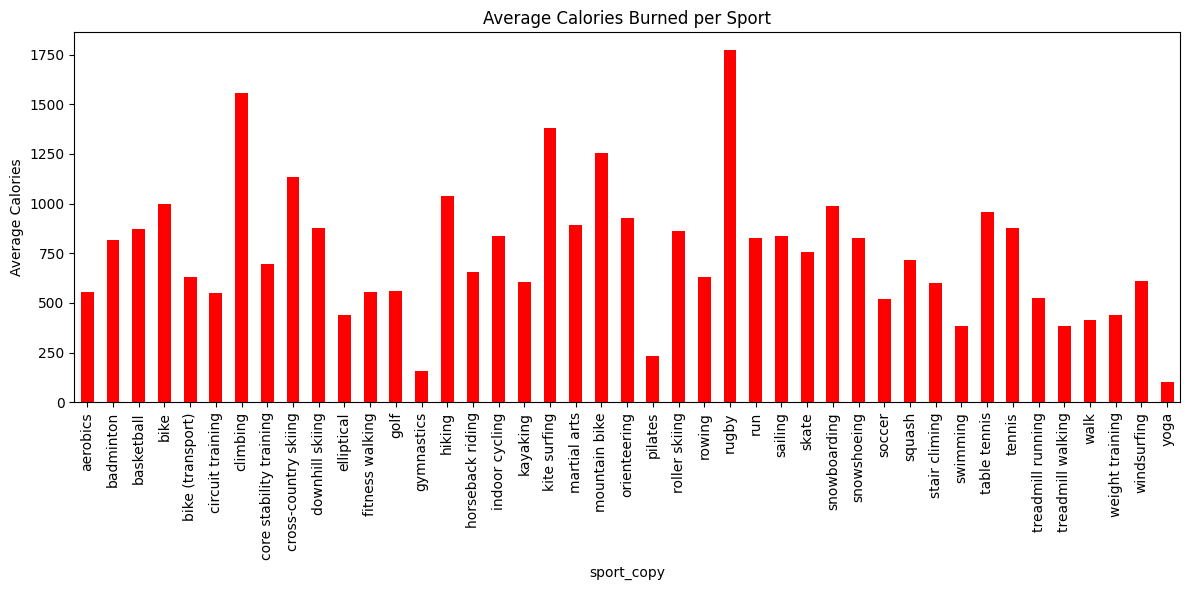

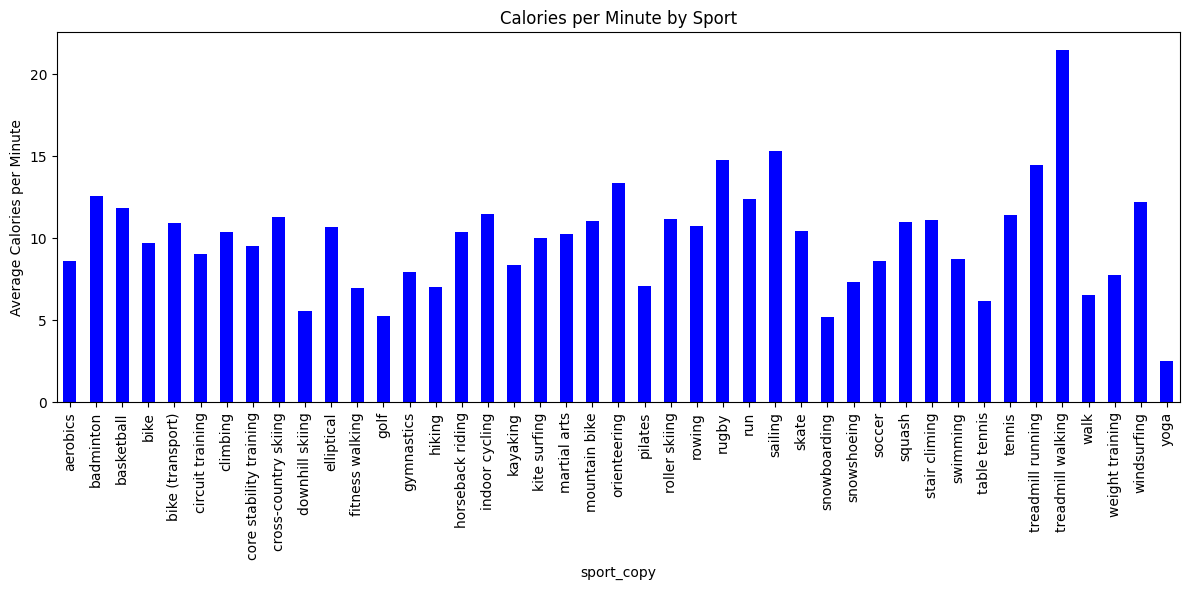

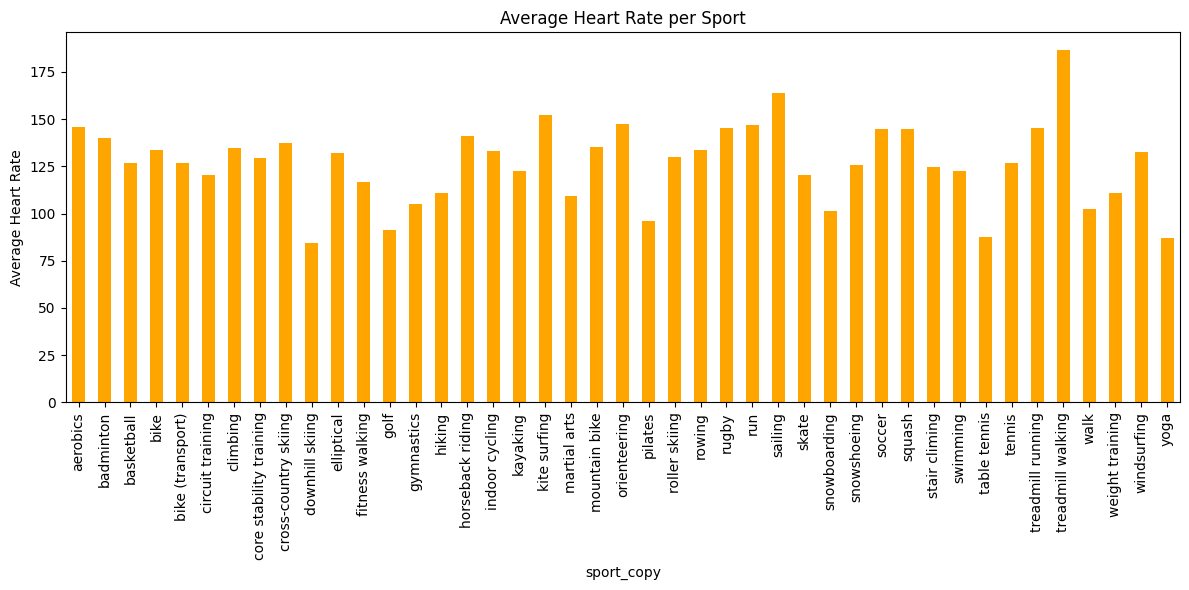

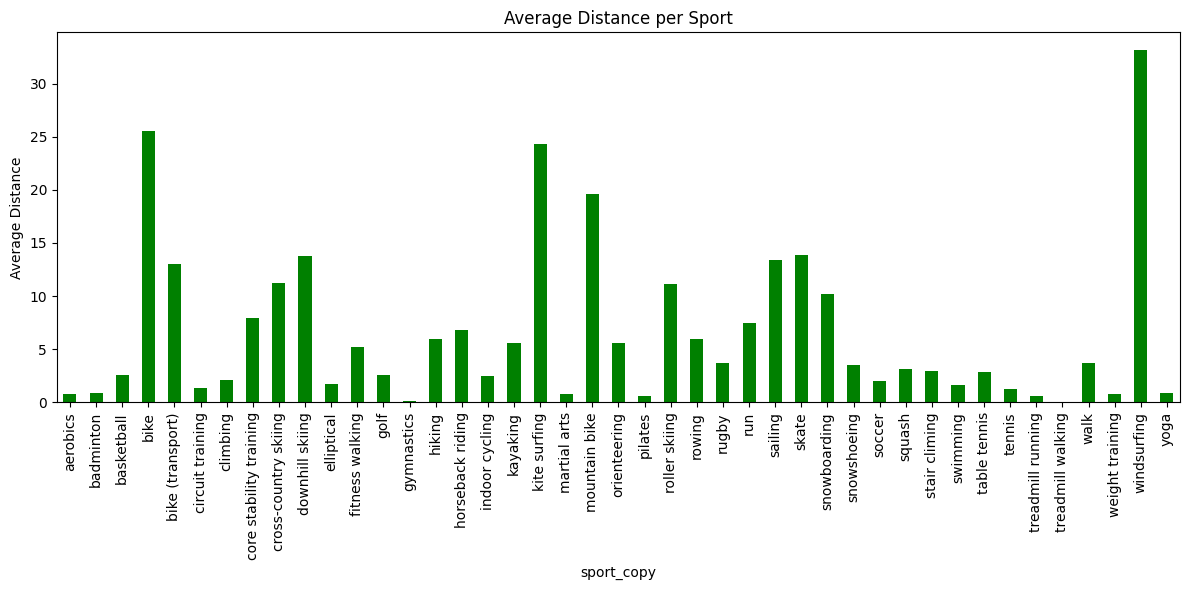

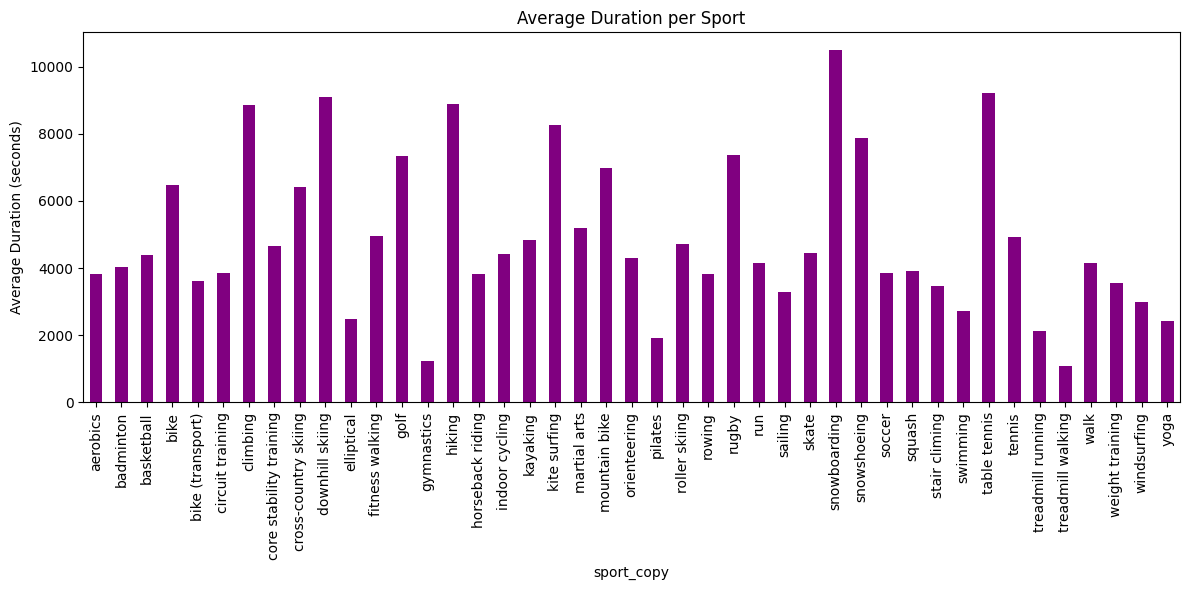

In [167]:
#Compute mean values for each sport
grouped_sport_stats = df.groupby("sport_copy")[["calories", "heart_rate", "distance", "duration", "calories_per_minute"]].mean()

#Average calories per sport
plt.figure(figsize=(12, 6))
grouped_sport_stats["calories"].plot(kind="bar", color="red")
plt.ylabel("Average Calories")
plt.title("Average Calories Burned per Sport")
plt.tight_layout()
plt.show()

#Average Calories by Sport
plt.figure(figsize=(12, 6))
grouped_sport_stats["calories_per_minute"].plot(kind="bar", color="blue")
plt.ylabel("Average Calories per Minute")
plt.title("Calories per Minute by Sport")
plt.tight_layout()
plt.show()


#Average heart rate per sport
plt.figure(figsize=(12, 6))
grouped_sport_stats["heart_rate"].plot(kind="bar", color="orange")
plt.ylabel("Average Heart Rate")
plt.title("Average Heart Rate per Sport")
plt.tight_layout()
plt.show()

#Average distance per sport
plt.figure(figsize=(12, 6))
grouped_sport_stats["distance"].plot(kind="bar", color="green")
plt.ylabel("Average Distance")
plt.title("Average Distance per Sport")
plt.tight_layout()
plt.show()

#Aerage duration per sport
plt.figure(figsize=(12, 6))
grouped_sport_stats["duration"].plot(kind="bar", color="purple")
plt.ylabel("Average Duration (seconds)")
plt.title("Average Duration per Sport")
plt.tight_layout()
plt.show()

In [168]:
df = df[['userId', 'sport', 'calories', 'duration','heart_rate','timestamp_start','timestamp_end']].dropna()

df = df[df['duration'] > 0]
df['calories_per_minute'] = df['calories'] / (df['duration'] / 60)

In [181]:
def train_test_split_chronological(df, test_size=0.2):
    training_ids = []
    testing_ids = []

    training_size = 1 - test_size

    uids = df['userId'].unique()
    for userId in uids:
        subset = df[df['userId'] == userId]
        values = np.sort(df[df['userId'] == userId].timestamp_start.values)

        # if only one values, make it appear in both
        training_length = int(training_size * len(values))
        if training_length <= 1:
            trainset = values
            testset = values
        else:
            trainset = values[:training_length]
            testset = values[training_length:]

        training_ids.extend(subset[subset['timestamp_start'].isin(trainset)].index)
        testing_ids.extend(subset[subset['timestamp_start'].isin(testset)].index)

    train_df, test_df = df.iloc[training_ids], df.iloc[testing_ids]

    return train_df, test_df

In [187]:
#Function to evaluate using SVD
def evaluate_svd(target_col):

    train_df, test_df = train_test_split_chronological(df, test_size=0.2)

    reader = Reader(rating_scale=(df[target_col].min(), df[target_col].max()))
    data = Dataset.load_from_df(train_df[['userId', 'sport', target_col]], reader)

    trainset = data.build_full_trainset()
    testset = test_df[['userId', 'sport', target_col]].values.tolist()

    model = SVD()
    model.fit(trainset)
    svd_preds = model.test(testset)

    # Baseline using global mean
    global_mean = df[target_col].mean()
    baseline_preds = [Prediction(uid, iid, true_r, global_mean, None) for (uid, iid, true_r) in testset]

    # Compute RMSEs
    rmse_svd = accuracy.rmse(svd_preds, verbose=False)
    rmse_mean = accuracy.rmse(baseline_preds, verbose=False)

    print(f"SVD RMSE:         {rmse_svd:.2f}")
    print(f"Global Mean RMSE: {rmse_mean:.2f}")

In [188]:
#Function to evaluate using KNN
def evaluate_knn(target_col):

    train_df, test_df = train_test_split_chronological(df, test_size=0.2)

    reader = Reader(rating_scale=(df[target_col].min(), df[target_col].max()))
    data = Dataset.load_from_df(train_df[['userId', 'sport', target_col]], reader)

    trainset = data.build_full_trainset()
    testset = test_df[['userId', 'sport', target_col]].values.tolist()

    model = KNNBaseline(sim_options={'name': 'cosine', 'user_based': False})
    model.fit(trainset)
    knn_preds = model.test(testset)

    #RMSEs
    rmse_knn = accuracy.rmse(knn_preds, verbose=False)
    print(f"KNN RMSE:         {rmse_knn:.2f}")


In [189]:
targets = ["calories", "calories_per_minute", "heart_rate"]

for t in targets:
    print(f"\n Results for: {t}")
    evaluate_knn(t)

    evaluate_svd(t)



 Results for: calories
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
KNN RMSE:         505.80
SVD RMSE:         3156.63
Global Mean RMSE: 558.58

 Results for: calories_per_minute
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
KNN RMSE:         3.21
SVD RMSE:         1223.12
Global Mean RMSE: 3.94

 Results for: heart_rate
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
KNN RMSE:         13.53
SVD RMSE:         75.08
Global Mean RMSE: 19.37
